# DASU-Net — 02 Model Architecture Comparison

This notebook compares the quantitative and qualitative performance of the **Baseline (ViT + Linear)** against the proposed **DASU-Net (Swin + DualAttn + NonLinear)** model.

We evaluate both architectures on two datasets: **Samson** and **Apex**.

In [1]:
import sys, os
import glob
import matplotlib.pyplot as plt
import numpy as np
# Ensure project root is on path
os.chdir(os.path.join(os.path.dirname(os.path.abspath('__file__')), '..'))
sys.path.insert(0, '.')

from src.utils.plotters import load_run, plot_loss_comparison, plot_abundances_comparison, plot_endmembers_comparison
from src.data import HyperspectralDataset

%matplotlib inline
plt.rcParams['figure.dpi'] = 120
print('Ready!')

Ready!


## 1. Samson Dataset Comparison

In [2]:
# Load Datasets and Runs
dataset_samson = HyperspectralDataset('samson', data_dir='./data/raw', device='cpu')
A_gt_samson = dataset_samson.get_abundance_cube().numpy()
E_gt_samson = dataset_samson.get_endmembers().numpy()
EM_NAMES_SAMSON = ['Soil', 'Tree', 'Water']

run_baseline_samson = load_run('runs/baseline_samson')
run_improved_samson = load_run('runs/dasunet_vca_samson')

runs_samson = [run_baseline_samson, run_improved_samson]
labels = ['Baseline (ViT+Linear)', 'DASU-Net + VCA']

In [3]:
print("=== Final Metrics (Samson) ===")
print("-" * 60)
print(f"{str('Model').ljust(35)} {'Mean RMSE':>10} {'Mean SAD':>10}")
print("-" * 60)
for r, l in zip(runs_samson, labels):
    print(f"{l.ljust(35)} {np.mean(r['rmse_cls']):>10.4f} {np.mean(r['sad_cls']):>10.4f}")
print("-" * 60)

=== Final Metrics (Samson) ===
------------------------------------------------------------
Model                                Mean RMSE   Mean SAD
------------------------------------------------------------
Baseline (ViT+Linear)                   0.2220     0.3789
DASU-Net + VCA                          0.1561     0.1648
------------------------------------------------------------


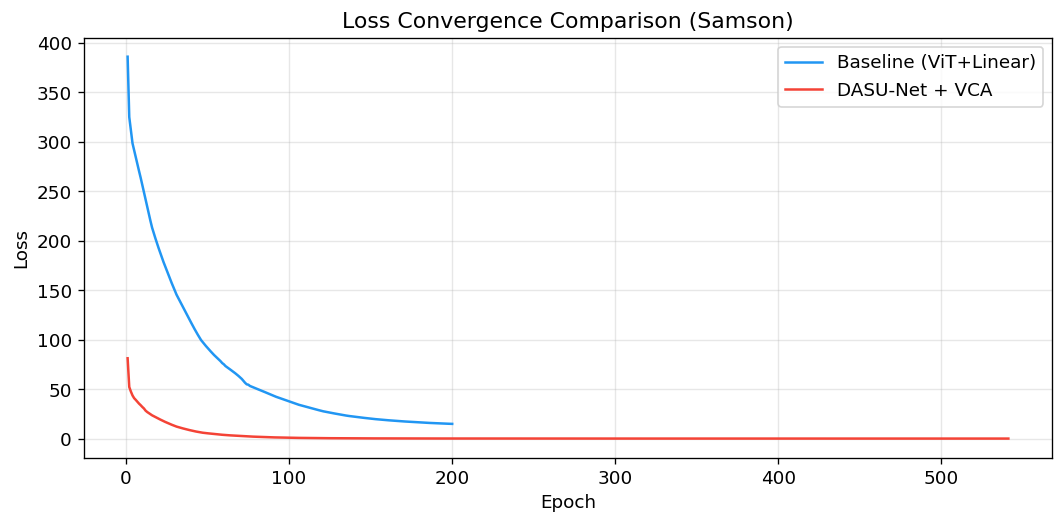

In [4]:
fig_loss = plot_loss_comparison(runs_samson, labels, title="Loss Convergence Comparison (Samson)")
plt.show()

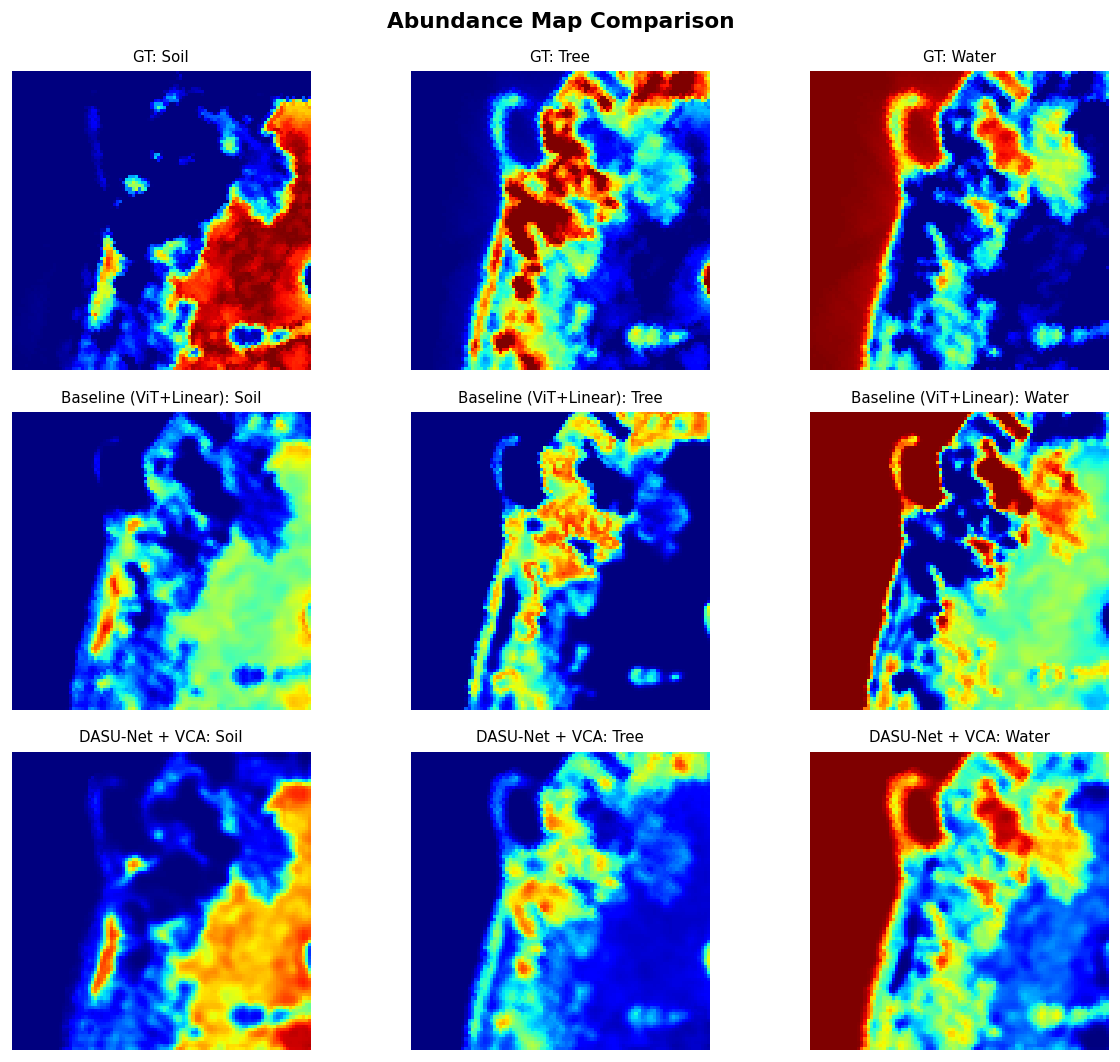

In [5]:
fig_abu = plot_abundances_comparison(runs_samson, labels, A_gt_samson, endmember_names=EM_NAMES_SAMSON)
plt.show()

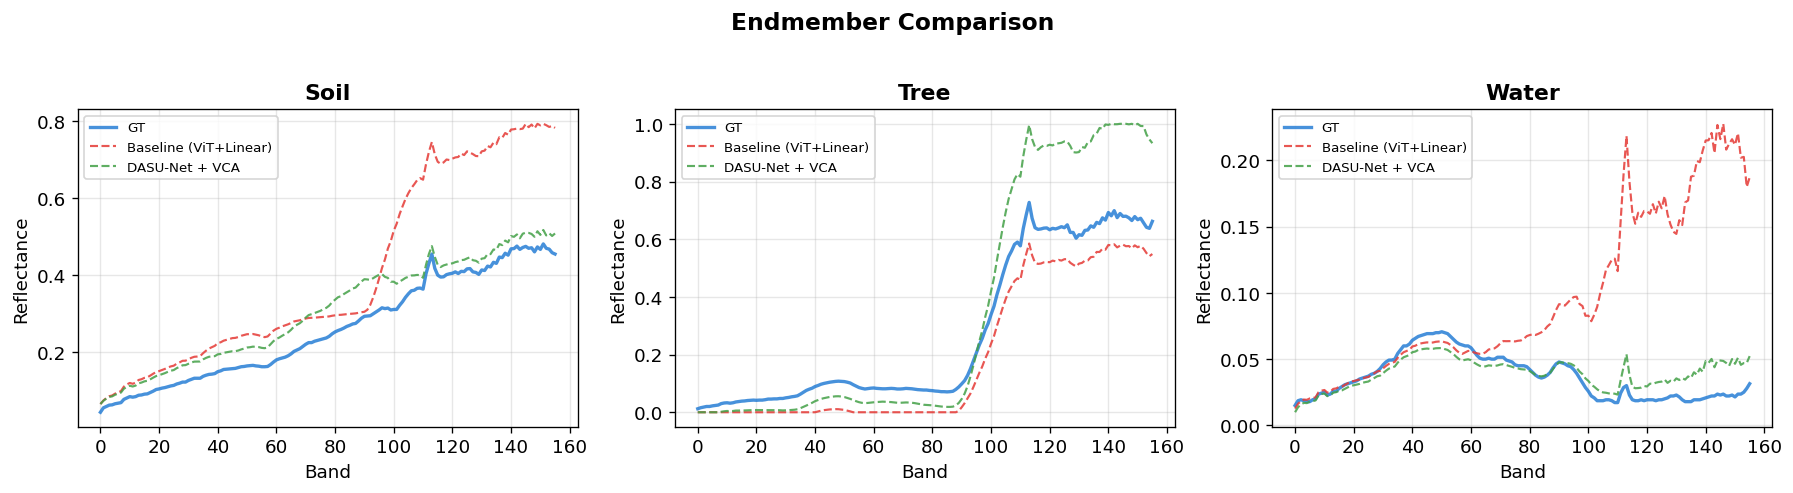

In [6]:
fig_end = plot_endmembers_comparison(runs_samson, labels, E_gt_samson, endmember_names=EM_NAMES_SAMSON)
plt.show()

## 2. Apex Dataset Comparison

In [7]:
# Load Datasets and Runs
dataset_apex = HyperspectralDataset('apex', data_dir='./data/raw', device='cpu')
A_gt_apex = dataset_apex.get_abundance_cube().numpy()
E_gt_apex = dataset_apex.get_endmembers().numpy()
EM_NAMES_APEX = ['Road', 'Tree', 'Roof', 'Water']

run_baseline_apex = load_run('runs/baseline_apex')
run_improved_apex = load_run('runs/dasunet_vca_apex')

runs_apex = [run_baseline_apex, run_improved_apex]

In [8]:
print("=== Final Metrics (Apex) ===")
print("-" * 60)
print(f"{str('Model').ljust(35)} {'Mean RMSE':>10} {'Mean SAD':>10}")
print("-" * 60)
for r, l in zip(runs_apex, labels):
    print(f"{l.ljust(35)} {np.mean(r['rmse_cls']):>10.4f} {np.mean(r['sad_cls']):>10.4f}")
print("-" * 60)

=== Final Metrics (Apex) ===
------------------------------------------------------------
Model                                Mean RMSE   Mean SAD
------------------------------------------------------------
Baseline (ViT+Linear)                   0.2321     0.2138
DASU-Net + VCA                          0.1926     0.2478
------------------------------------------------------------


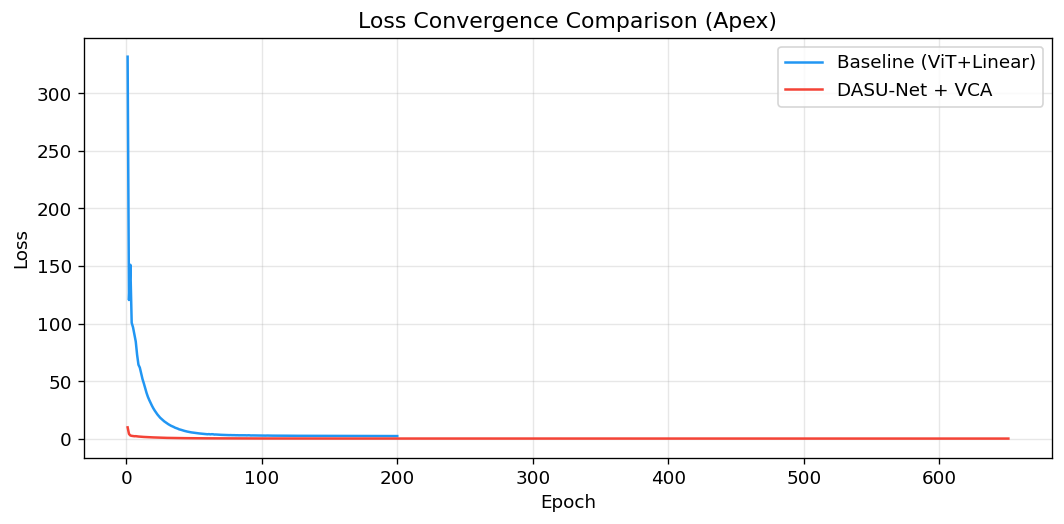

In [9]:
fig_loss = plot_loss_comparison(runs_apex, labels, title="Loss Convergence Comparison (Apex)")
plt.show()

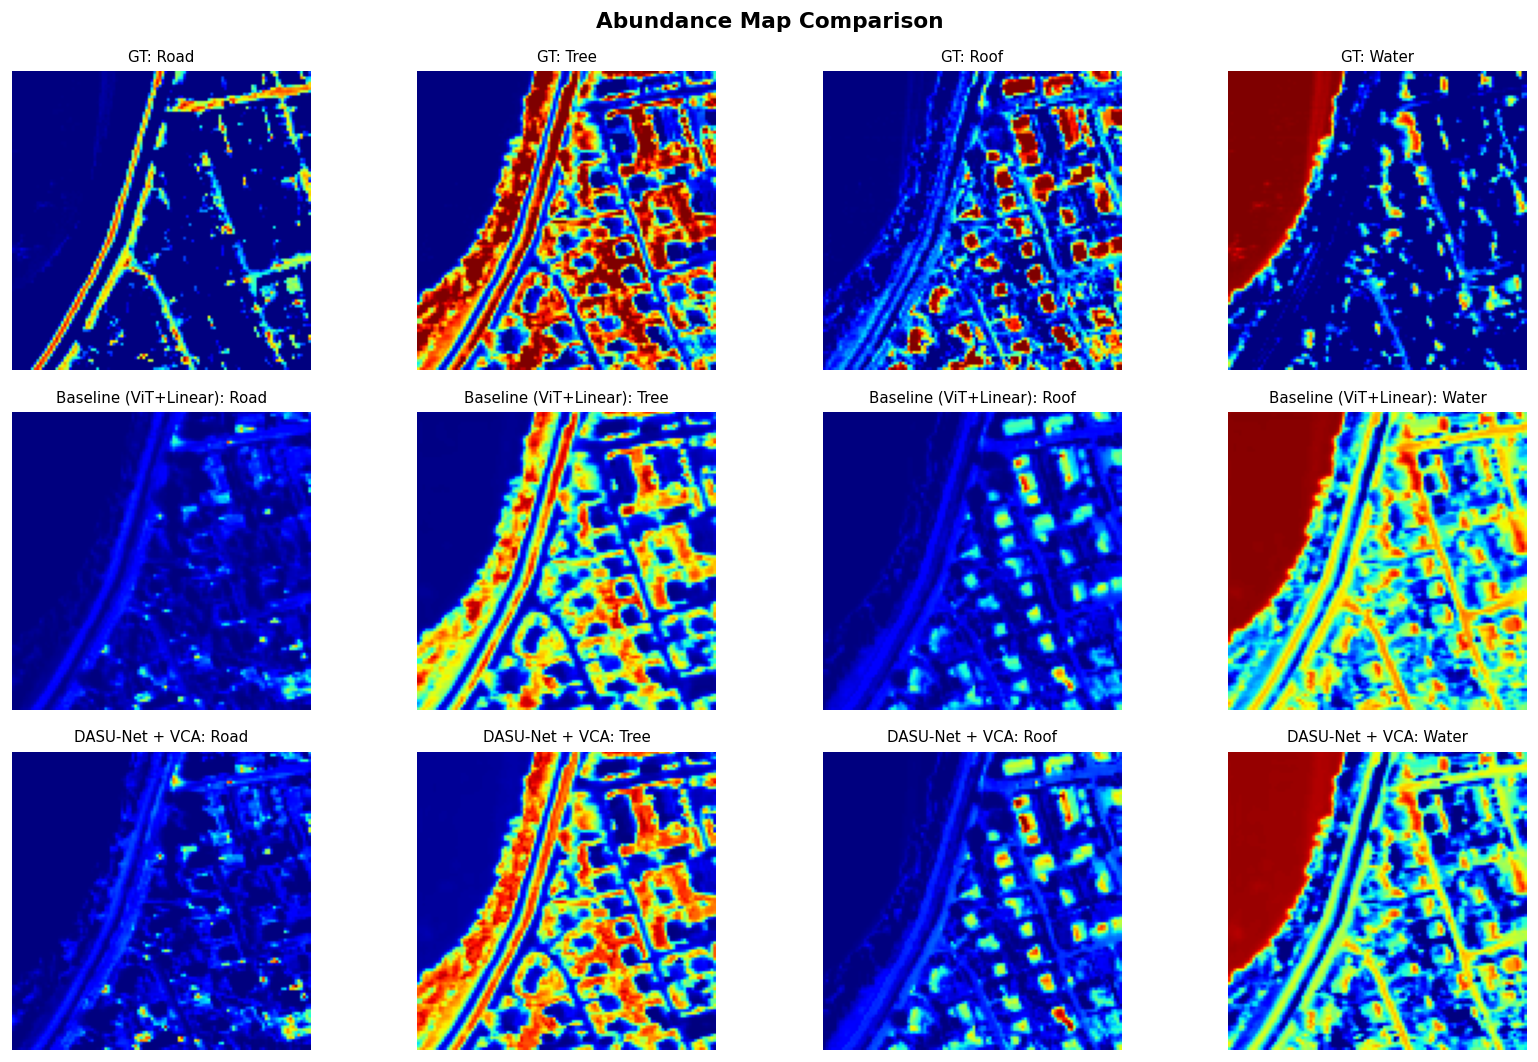

In [10]:
fig_abu = plot_abundances_comparison(runs_apex, labels, A_gt_apex, endmember_names=EM_NAMES_APEX)
plt.show()

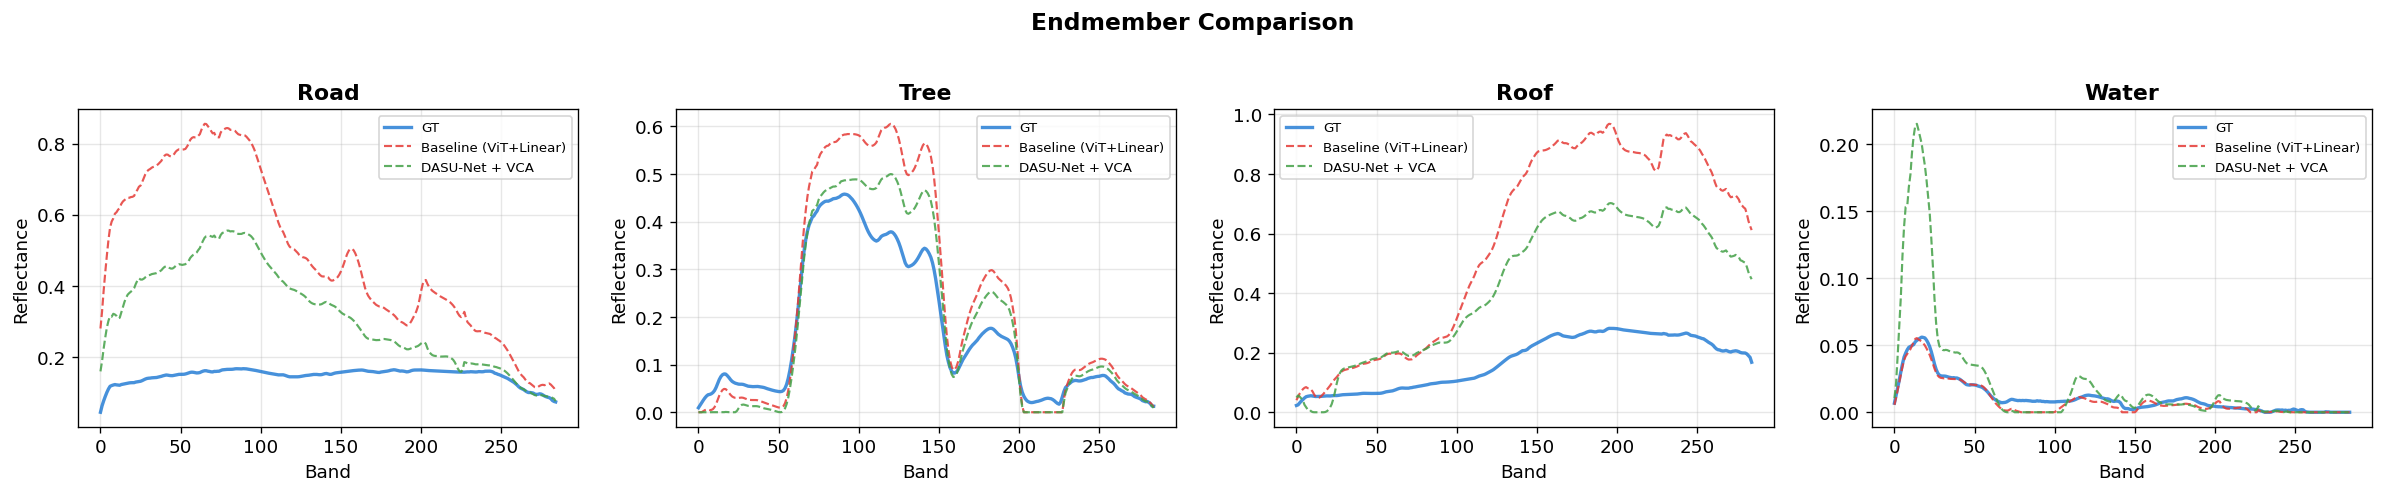

In [11]:
fig_end = plot_endmembers_comparison(runs_apex, labels, E_gt_apex, endmember_names=EM_NAMES_APEX)
plt.show()